# 04 — CTD-switch / delivery optionality

**Idea.** The basis is *long* the short's delivery options (quality/switch, timing, end-of-month). Harvest that optionality: go **long the basis** when the option looks **cheap and likely to pay** — net basis at/below its trailing mean, **elevated realised futures vol**, and a **small CTD-vs-runner-up IRR gap** (a CTD switch is near). Long-only proxy, per tenor, with the same correct PnL + financing.

> Simplified, transparent proxy for the optionality/switch trade (full wild-card/EOM valuation is out of scope). Uses `build_basis_panel` (with `irr_gap`) + `ctd_optionality_signal`.

In [1]:
import sys, os
REPO = r"C:\\Users\\chris\\clee\\ARBS"
if REPO not in sys.path:
    sys.path.insert(0, REPO)
import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.options.display.float_format = lambda x: f'{x:,.2f}'
from BT.signals.ustf_basis import (UstfBasisConfig, build_basis_panel, ctd_optionality_signal,
                                   run_ustf_basis_signal_backtest, plot_pnl)
from MDP.USTFutures.USTFuturesMDP import USTFuturesMDP

In [2]:
START, END = datetime.date(2024, 6, 1), datetime.date(2026, 5, 31)
TENORS = ["TU", "FV", "TY", "US"]
SPECIALNESS_BPS = {"TU": 5.0, "FV": 8.0, "TY": 10.0, "US": 12.0}  # CTD repo specialness
cfg = UstfBasisConfig(tenors=TENORS, start=START, end=END, bond_face=100_000_000.0,
                      specialness_bps=SPECIALNESS_BPS, tx_cost_32nds=0.5, show_progress=True)
mdp = USTFuturesMDP(source='BARCHART_USTF-RL')
VOL_WINDOW, VOL_Q, IRR_GAP_MAX = 21, 0.6, 0.10

BACKTESTING...:   0%|          | 0/497 [00:00<?, ?step/s]

BACKTESTING...:  39%|███▉      | 196/497 [00:00<00:01, 196.66step/s]

BACKTESTING...:  43%|████▎     | 216/497 [00:01<00:02, 135.04step/s]

BACKTESTING...:  46%|████▌     | 227/497 [00:01<00:02, 120.58step/s]

BACKTESTING...:  49%|████▉     | 245/497 [00:01<00:02, 115.78step/s]

...

Failed to fetch pricer for 91282CQF1 @ 2026-03-30 14:00:00-05:00: 'FedInvest snapshot missing CUSIP 91282CQF1 for 2026-03-30 14:00:00-05:00'


BACKTESTING...: 100%|██████████| 497/497 [00:08<00:00, 56.92step/s] 

BACKTESTING...:   0%|          | 0/497 [00:00<?, ?step/s]

BACKTESTING...:  91%|█████████▏| 454/497 [00:00<00:00, 650.66step/s]

BACKTESTING...: 100%|██████████| 497/497 [00:10<00:00, 49.33step/s] 

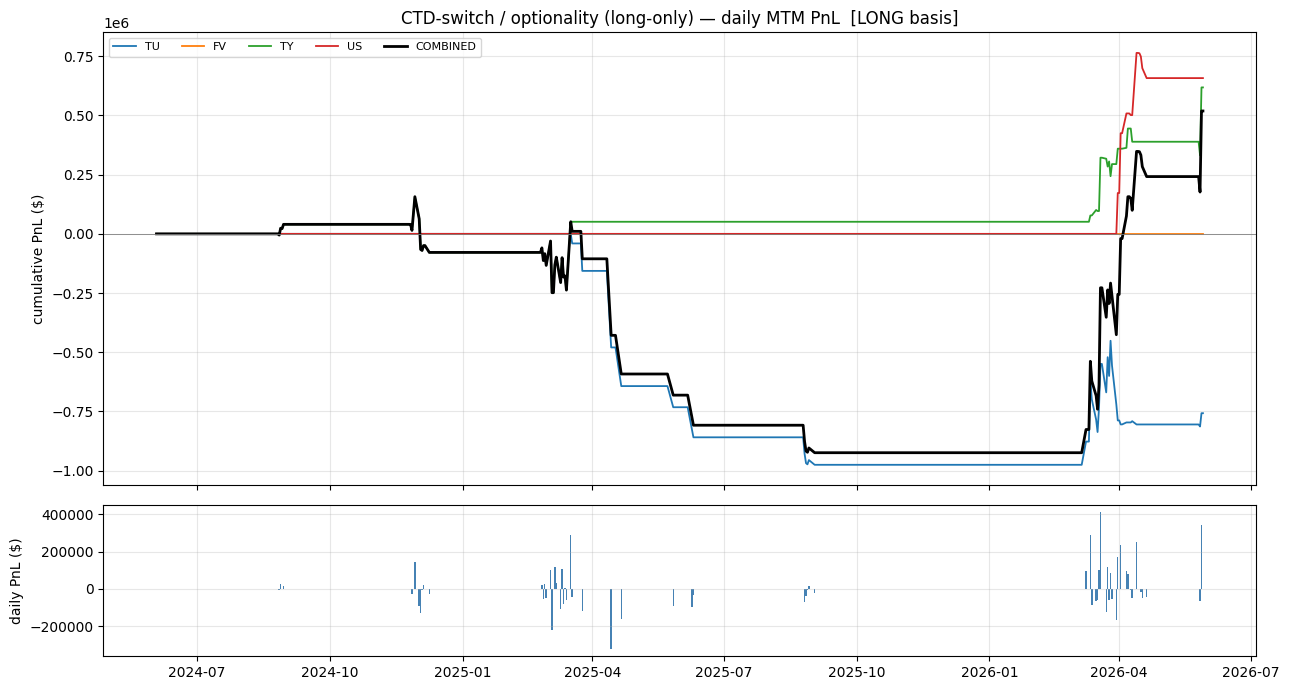

In [3]:
panels = {t: build_basis_panel(t, START, END, roll_days=cfg.roll_days_before_first_notice, mdp=mdp) for t in TENORS}
signal = ctd_optionality_signal(vol_window=VOL_WINDOW, vol_quantile=VOL_Q, irr_gap_max=IRR_GAP_MAX)
res = run_ustf_basis_signal_backtest(cfg, signal, mdp=mdp, panels=panels)
fig = plot_pnl(res, title='CTD-switch / optionality (long-only) — daily MTM PnL')

## Diagnostics (example tenor): IRR gap to runner-up + realised vol

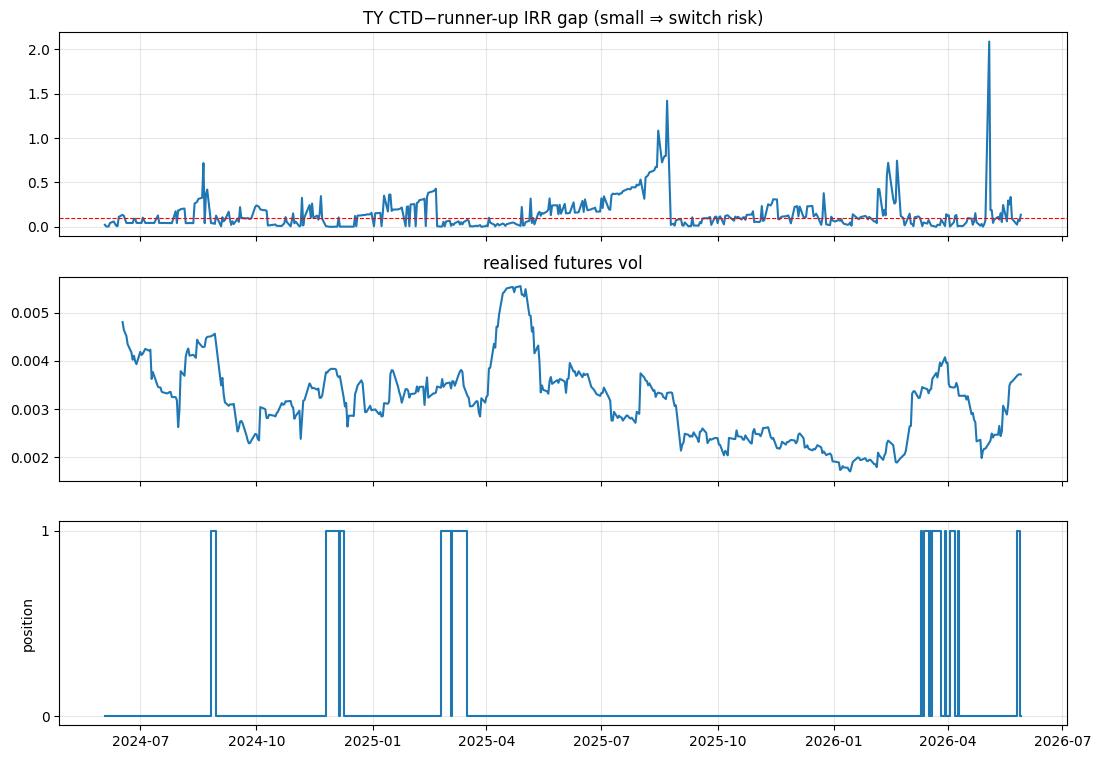

In [4]:
t = 'TY'; panel = panels[t]
rv = panel['future_price'].astype(float).pct_change().rolling(VOL_WINDOW, min_periods=10).std()
fig, (a1, a2, a3) = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
a1.plot(panel.index, panel['irr_gap']); a1.axhline(IRR_GAP_MAX, color='r', ls='--', lw=0.8); a1.set_title(f'{t} CTD−runner-up IRR gap (small ⇒ switch risk)'); a1.grid(alpha=0.3)
a2.plot(rv.index, rv); a2.set_title('realised futures vol'); a2.grid(alpha=0.3)
a3.plot(res.signals_by_tenor[t].index, res.signals_by_tenor[t], drawstyle='steps-post'); a3.set_ylabel('position'); a3.set_yticks([0, 1]); a3.grid(alpha=0.3)
plt.show()